In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
import tensorflow as tf 
from tensorflow.keras import Sequential 
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization 
import seaborn as sns
from tensorflow.keras.layers import LeakyReLU
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.utils import resample

import joblib
import time
# import smogn

In [ ]:

#  Clean the dataset
def clean_dataset(df):
    df_clean = df.copy()
    for col in df_clean.select_dtypes(include=[np.number]).columns:
        df_clean[col] = df_clean[col].replace([np.inf, -np.inf], np.nan)
        if df_clean[col].notnull().any():
            q_low = df_clean[col].quantile(0.001)
            q_high = df_clean[col].quantile(0.999)
            df_clean[col] = df_clean[col].clip(lower=q_low, upper=q_high)
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
    return df_clean

#  Load and preprocess
file_path = '../../car_data_v1_3.csv'
df = pd.read_csv(file_path)
df = clean_dataset(df)

selected_columns = ['Cod_fasecolda', 'Modelo', 'Kilometraje', 'Year', 'Month', 'Ubicacion_int', 'Demanda', 'Promedio_estrellas', 'Combustible', 'Descripcion_int', 'Gama', 'Blindaje', 'Estado_vehiculo_int', 'Servicio_int', 'Estado_vitrina','Pricing']
print(df.columns.tolist())

df = df[[col for col in selected_columns if col in df.columns]]

print(df.shape)

df['Estado_vitrina'] = (
    df['Estado_vitrina']
    .str.lower()          # Convierte a minúsculas
    .str.strip()          # Elimina espacios al inicio y final
    .str.replace(r'\s+', '_', regex=True)  # Reemplaza espacios internos por guiones bajos
)
reemplazos = {
    'venta_especial': 'venta_especial',
    'venta_especial_': 'venta_especial',
    'venta_especiales': 'venta_especial',
    'venta espcial' : 'venta_especial',
    'venta_espcial' : 'venta_especial'
    # Agrega más reemplazos según sea necesario
}

df['Estado_vitrina'] = df['Estado_vitrina'].replace(reemplazos)
# df = df.head(500)
# df = df.astype(float)
df['Cod_fasecolda'] = df['Cod_fasecolda'].astype(str).str.zfill(8)
df['Marca_cod'] = df['Cod_fasecolda'].str[:3]
df['Tipolo_cod'] = df['Cod_fasecolda'].str[3:5]
df['Resto_cod'] = df['Cod_fasecolda'].str[5:]

df['Marca_cod'] = df['Marca_cod'].astype(int)
df['Tipolo_cod'] = df['Tipolo_cod'].astype(int)
df['Resto_cod'] = df['Resto_cod'].astype(int)
df['Cod_fasecolda'] = df['Cod_fasecolda'].astype(int)

print(df.columns.tolist())

print(df.shape)
df['Modelo'] = df['Modelo'].replace('-', np.nan)
df = df.dropna(subset=['Modelo'])
df['Kilometraje'] = df['Kilometraje'].replace('-', 0)
df['Kilometraje'] = df['Kilometraje'].replace(r'[^\d.-]', '', regex=True)  # Elimina caracteres no numéricos

df['Kilometraje'] = pd.to_numeric(df['Kilometraje'], errors='coerce').fillna(0)  # Convierte a float
df['Pricing'] = pd.to_numeric(df['Pricing'], errors='coerce')
df = df.dropna(subset=['Pricing'])
for i in selected_columns:
    if i == 'Combustible' or i == 'Gama' or i == 'Estado_vitrina':
        pass
    else:
        df[i] = df[i].astype(float)

df.drop(columns='Cod_fasecolda', inplace=True)
## ------------- categorical --------------------------------------------------------------------------
df = pd.get_dummies(df, columns=['Combustible'], prefix='Combustible')
df = pd.get_dummies(df, columns=['Gama'], prefix='Gama')
df = pd.get_dummies(df, columns=['Estado_vitrina'], prefix='Vitrina')
# df.drop(columns=['Combustible', 'Gama', 'Estado_vitrina'], inplace=True)
df.drop(columns=['Gama_De Lujo ', 'Combustible_HBD', 'Vitrina_vitrina'], inplace=True)



X = df.drop(columns=['Pricing'])
y = df['Pricing']
y_log = np.log1p(y)
# y_log = y
y_log = y_log/50
# X['Kilometraje'] = X['Kilometraje']/1e8
# X['Modelo'] = X['Modelo']/1e4
# X['Year'] = X['Year']/1e4
# X['Month'] = X['Month']/12
# X['Promedio_estrellas'] = X['Promedio_estrellas']/5
# X['Marca_cod'] = X['Marca_cod']/1000
# X['Tipolo_cod'] = X['Tipolo_cod']/100
# X['Resto_cod'] = X['Resto_cod']/1000


C:\Users\manuel.torres\AppData\Local\Temp\ipykernel_23708\565079860.py:15: DtypeWarning: Columns (4,11,29,33) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


['Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0', 'Estado_vehiculo', 'Referencia_old', 'Fecha_venta', 'Modelo', 'Cod_fasecolda', 'Marca', 'Linea', 'Referencia', 'Kilometraje', 'Year', 'Month', 'Ubicacion', 'Ubicacion_int', 'MPIO_CDPMP', 'Servicio', 'Servicio_int', 'Estado_vitrina', 'Estado_vitrina_int', 'Gama', 'Gama_int', 'Group_number', 'Demanda', 'Sales', 'Promedio_estrellas', 'Combustible', 'Combustible_int', 'Descripcion', 'Descripcion_int', 'Blindaje', 'Estado_vehiculo_int', 'Pricing']
(1440804, 16)
['Cod_fasecolda', 'Modelo', 'Kilometraje', 'Year', 'Month', 'Ubicacion_int', 'Demanda', 'Promedio_estrellas', 'Combustible', 'Descripcion_int', 'Gama', 'Blindaje', 'Estado_vehiculo_int', 'Servicio_int', 'Estado_vitrina', 'Pricing', 'Marca_cod', 'Tipolo_cod', 'Resto_cod']
(1440804, 19)


In [5]:
print(y_log.max()/50)
print(X['Kilometraje'].max()/1e8)
print(X['Modelo'].max()/1e4)
print(X['Year'].max()/1e4)
print(X['Month'].max()/12)
print(X['Promedio_estrellas'].max()/5)
print(X['Marca_cod'].max()/1000)
print(X['Tipolo_cod'].max()/100)
print(X['Resto_cod'].max()/1000)

0.008307805235671172
0.41126254
0.2025
0.2025
1.0
1.0
0.432
0.99
0.998


In [6]:
# Falta normalizar los valores para que sean entre 0 y 1



In [7]:

## -------------- bootstraping ------------------------------------------------------------------------------
df_bootstrap = pd.concat([X, y_log], axis=1)

# Bootstrapping: generate a new dataset by sampling with replacement
df_bootstrap = resample(
    df_bootstrap,
    replace=True,
    n_samples=int(len(df_bootstrap) * 1.5),  # You can increase size; 1.5x is common
    random_state=42
)

# Separate the bootstrapped data
X = df_bootstrap.drop(columns=['Pricing'])
y_log = df_bootstrap['Pricing']
## ..........................................................................................................

print(df.shape)

# split the data
scaler = StandardScaler()
X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.3, random_state=42)
print(X_train.columns.tolist())
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
y_test_orig = np.expm1(y_test)
y_test_orig_log = y_test




(1440715, 23)
['Modelo', 'Kilometraje', 'Year', 'Month', 'Ubicacion_int', 'Demanda', 'Promedio_estrellas', 'Descripcion_int', 'Blindaje', 'Estado_vehiculo_int', 'Servicio_int', 'Marca_cod', 'Tipolo_cod', 'Resto_cod', 'Combustible_DSL', 'Combustible_ELT', 'Combustible_GAS', 'Combustible_GSL', 'Gama_Gama Alta', 'Gama_Gama Baja', 'Gama_Gama Media', 'Vitrina_venta_especial']


In [8]:
from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())
print("Num GPUs Available:", len(tf.config.experimental.list_physical_devices('GPU')))

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 9099076740494333894
xla_global_id: -1
]
Num GPUs Available: 0


In [9]:

# def nn_model():
#     model = Sequential()
#     model.add(Dense(64, activation='relu', input_shape=[len(X_train.keys())]))
#     model.add(Dropout(0.2))
#     model.add(Dense(100, activation='relu'))
#     model.add(Dropout(0.2))
#     model.add(BatchNormalization())
#     model.add(Dense(50, activation='relu'))
#     model.add(Dense(10, activation='relu'))
#     model.add(Dense(1))

#     return model 

# model = nn_model()
def nn_model():
    model = Sequential([
        Dense(228, activation='relu', input_shape=[X_train.shape[1]]),
        BatchNormalization(),
        Dropout(0.3),
        Dense(150, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        BatchNormalization(),
        Dense(100, activation='relu'),
        Dropout(0.2),
        Dense(60, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    return model

# def nn_model():
#     model = Sequential([
#         Dense(128, kernel_initializer='he_normal'),
#         BatchNormalization(),
#         LeakyReLU(),
#         Dropout(0.3),

#         Dense(100, kernel_regularizer=tf.keras.regularizers.l2(1e-4), kernel_initializer='he_normal'),
#         BatchNormalization(),
#         LeakyReLU(),

#         Dense(50, kernel_regularizer=tf.keras.regularizers.l2(1e-4), kernel_initializer='he_normal'),
#         LeakyReLU(),
#         Dropout(0.2),

#         Dense(32, activation='relu'),
#         Dense(1)
#     ])
#     return model
model = nn_model()

print(model.summary())

c:\Users\manuel.torres\AppData\Local\anaconda3\envs\mldata\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 228)            │         5,244 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 228)            │           912 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 228)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 150)            │        34,350 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 150)            │           600 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        15,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 60)             │         6,060 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,251 (250.98 KB)

 Trainable params: 63,495 (248.03 KB)

 Non-trainable params: 756 (2.95 KB)

None


In [10]:
# print(tf.debugging.set_log_device_placement(True))

In [11]:
# optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

# model.compile(optimizer=optimizer,
#               loss='mse',
#               metrics=['mse'])

# decay_lr = tf.keras.callbacks.LearningRateScheduler(lambda x: 1e-3*0.99**x)
# early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# history = model.fit(X_train, y_train, epochs=70, callbacks=[early_stop, decay_lr], validation_split=0.2, verbose=0)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae', 'mse'])

early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
lr_reduce = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
decay_lr = tf.keras.callbacks.LearningRateScheduler(lambda x: 1e-3*0.975**x)
# X_train = np.array(X_train, dtype=np.float32)
# y_train = np.array(y_train, dtype=np.float32)

# tf.debugging.set_log_device_placement(True)

history = model.fit(X_train, y_train, validation_split=0.2, epochs=200, batch_size=128,
                    callbacks=[early_stop, decay_lr], verbose=1)

Epoch 1/200
9455/9455 ━━━━━━━━━━━━━━━━━━━━ 37s 4ms/step - loss: 0.0434 - mae: 0.0258 - mse: 0.0059 - val_loss: 1.6260e-04 - val_mae: 0.0065 - val_mse: 1.3508e-04 - learning_rate: 0.0010
Epoch 2/200
9455/9455 ━━━━━━━━━━━━━━━━━━━━ 34s 4ms/step - loss: 1.5624e-04 - mae: 0.0065 - mse: 1.3190e-04 - val_loss: 1.2222e-04 - val_mae: 0.0053 - val_mse: 1.1812e-04 - learning_rate: 9.7500e-04
Epoch 3/200
9455/9455 ━━━━━━━━━━━━━━━━━━━━ 35s 4ms/step - loss: 1.0915e-04 - mae: 0.0051 - mse: 1.0334e-04 - val_loss: 1.1935e-04 - val_mae: 0.0059 - val_mse: 1.1517e-04 - learning_rate: 9.5062e-04
Epoch 4/200
9455/9455 ━━━━━━━━━━━━━━━━━━━━ 35s 4ms/step - loss: 1.0518e-04 - mae: 0.0049 - mse: 1.0026e-04 - val_loss: 9.7618e-05 - val_mae: 0.0044 - val_mse: 9.2079e-05 - learning_rate: 9.2686e-04
Epoch 5/200
9455/9455 ━━━━━━━━━━━━━━━━━━━━ 34s 4ms/step - loss: 1.0256e-04 - mae: 0.0048 - mse: 9.7793e-05 - val_loss: 9.6534e-05 - val_mae: 0.0044 - val_mse: 9.1999e-05 - learning_rate: 9.0369e-04
Epoch 6/200
9455/9455 

KeyboardInterrupt: 

In [ ]:
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch 
hist.tail()

,loss,mae,mse,val_loss,val_mae,val_mse,learning_rate,epoch
37,0.000095,0.004443,0.000092,0.000101,0.004368,0.000098,0.000392,37
38,0.000095,0.004434,0.000092,0.000103,0.004497,0.000100,0.000382,38
39,0.000095,0.004425,0.000092,0.000103,0.004428,0.000100,0.000373,39
40,0.000095,0.004421,0.000092,0.000099,0.004257,0.000097,0.000363,40
41,0.000095,0.004420,0.000092,0.000100,0.004378,0.000097,0.000354,41


In [ ]:
def plot_history(history):
    hist = pd.DataFrame(history.history)
    hist['epoch'] = history.epoch 

    plt.figure()
    plt.xlabel('Epoch')
    plt.ylabel('Mean Square Error')
    plt.plot(hist['epoch'], hist['mse'], 'r--', label='Trainign Error')
    plt.plot(hist['epoch'], hist['val_mse'], 'b', label='Validation Error')
    plt.ylim([0,0.001])
    plt.legend()
    plt.show()


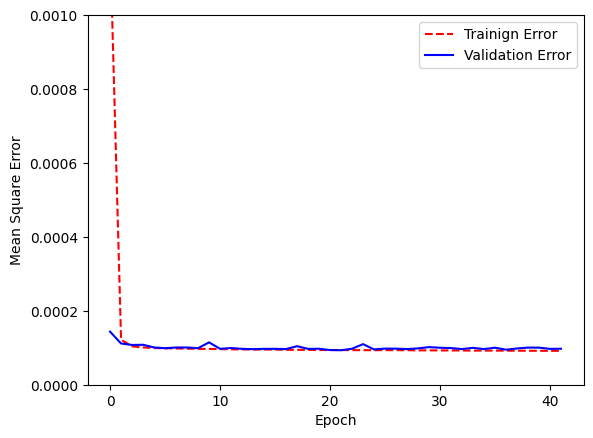

In [ ]:
plot_history(history)

In [ ]:
# X_test = np.array(X_test, dtype=np.float32)
# y_test = np.array(y_test, dtype=np.float32)
loss, mae, mse = model.evaluate(X_test, y_test)
print(f'Test MAE: {mae:.2f}, Test MSE: {mse:.2f}')



20095/20095 ━━━━━━━━━━━━━━━━━━━━ 19s 929us/step - loss: 9.3636e-05 - mae: 0.0039 - mse: 9.0289e-05
Test MAE: 0.00, Test MSE: 0.00


In [ ]:
y_pred_log = model.predict(X_test, verbose=0)
y_pred = np.expm1(y_pred_log*50)
print(y_pred)

rmse = np.sqrt(mean_squared_error(y_test_orig_log, y_pred_log))

[[27646976.]
 [69635064.]
 [13276149.]
 ...
 [50167640.]
 [59829712.]
 [29732072.]]


In [ ]:
print('rmse: ',rmse)
r2 = r2_score(y_test_orig_log, y_pred_log)
print('R2: ', r2)

rmse:  0.009425173351120525
R2:  0.6248950353704616


In [ ]:
model.save("../../my_nn_model_pricing_13_05.keras")
joblib.dump(scaler, '../../scaler_13_05.pkl')
# el 3 dio mejores resultados

['../scaler_4.pkl']

In [ ]:
import tensorflow as tf
print("Num GPUs Available:", len(tf.config.experimental.list_physical_devices('GPU')))


Num GPUs Available: 0
